# Niche Query on CCF Dataset


Experiment setup:
- Niche: k-hop neighboring cells across brain sections;
- Positive pairs: RM-ideal.

## Load Data

In [1]:

import logging

# sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
logging.basicConfig(level=logging.INFO)

## QueST Embedding

In [2]:
# load data
import numpy as np
import pandas as pd
import torch
import os
import scanpy as sc


def load_emb(adata_folder, emb_folder, emb_key, suffix='pt', update_anndata=True):
    adata_list = []
    fnames = [fname for fname in os.listdir(adata_folder)]
    fnames.sort()
    for fname in fnames:
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)
        if embedding_key in adata.obsm:
            print(f"[SKIP] embedding exists for {fname}")
            continue

        emb_path = os.path.join(emb_folder, f"{stem}.{suffix}")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        if suffix == 'csv':
            emb = pd.read_csv(emb_path, index_col=0).values.astype(np.float64)
        elif suffix == 'pt':
            emb_tensor = torch.load(emb_path, map_location="cpu")
            emb = emb_tensor.detach().cpu().numpy()
        else:
            print(f"[SKIP] not supported suffix {fname}")
            continue

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        if update_anndata:
            adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = '/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/notebook/ccf/data/benchmark_samples/20260414_235933'
emb_folder = '/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419'
embedding_key = 'X_quest_emb'
adata_list = load_emb(adata_folder, emb_folder, emb_key=embedding_key, suffix='pt')

[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/C57BL6J-638850.28.pt
[DONE] C57BL6J-638850.28
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/C57BL6J-638850.29.pt
[DONE] C57BL6J-638850.29
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/C57BL6J-638850.30.pt
[DONE] C57BL6J-638850.30
[SKIP] No embedding for C57BL6J-638850.31.h5ad
[SKIP] No embedding for Zhuang-ABCA-1.096.h5ad
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/Zhuang-ABCA-1.097.pt
[DONE] Zhuang-ABCA-1.097
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/Zhuang-ABCA-1.098.pt
[DONE] Zhuang-ABCA-1.098
[

In [3]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery
import os

# step 1: create db
zhuang_abca_1_folder = 'notebook/ccf/data/zhuang-abca-1/'
zhuang_abca_2_folder = 'notebook/ccf/data/zhuang-abca-2/'
zhuang_abca_3_folder = 'notebook/ccf/data/zhuang-abca-3/'
zeng_mwb_folder = 'notebook/ccf/data/zeng-mwb/'
sample_data_folder = 'notebook/ccf/data/benchmark_samples/20260414_235933'

target_sample_ids = [
    'Zhuang-ABCA-1.098', 'Zhuang-ABCA-1.099', 'Zhuang-ABCA-1.097', #'Zhuang-ABCA-1.096',
    #'Zhuang-ABCA-2.046', 'Zhuang-ABCA-2.047', 'Zhuang-ABCA-2.048', #'Zhuang-ABCA-2.050',
    #'Zhuang-ABCA-3.001', 'Zhuang-ABCA-3.002', 'Zhuang-ABCA-3.004', #'Zhuang-ABCA-3.005',
    'C57BL6J-638850.28', 'C57BL6J-638850.29', 'C57BL6J-638850.30', #'C57BL6J-638850.31'
]

db = Database(target_sample_ids)

db.construct(
    adata_path=[
        sample_data_folder + '/' + sample_id + '.h5ad'
        for sample_id in target_sample_ids
    ],
    cell_metadata_path=[
        zhuang_abca_1_folder + 'cell_metadata.csv',
        zhuang_abca_2_folder + 'cell_metadata.csv',
        zhuang_abca_3_folder + 'cell_metadata.csv',
        zeng_mwb_folder + 'cell_metadata.csv',
    ],
    ccf_coordinates_path=[
        zhuang_abca_1_folder + 'ccf_coordinates.csv',
        zhuang_abca_2_folder + 'ccf_coordinates.csv',
        zhuang_abca_3_folder + 'ccf_coordinates.csv',
        zeng_mwb_folder + 'ccf_coordinates.csv',
    ],
    feature_name=embedding_key,
    parcellation_path='notebook/ccf/data/parcellation/structure.json'
)

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Loading CCF coordinates...
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:361: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunksize=_METADATA_CSV_CHUNKSIZE):
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:361: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunk

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:225: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'sample_id' as categorical


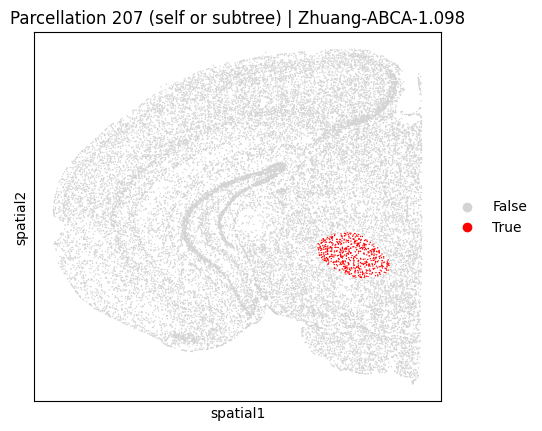

In [4]:
target_parcellation = 207
query_niche_sample_id = 'Zhuang-ABCA-1.098'

db.get_sample(query_niche_sample_id).visualize_parcellation_cells(
    target_parcellation_index=target_parcellation,
    # print_metadata=True,
    spot_size=0.02,
    # metadata_txt_path=f'notebook/ccf/data/benchmark_samples/center_cells/{query_niche_sample_id}_parcellation_207.txt'
)

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.098 slice.
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.098')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:249: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


Niche cells by parcellation (n_total=100):
  parcellation_index=207  parcellation_name='Area postrema'  n_cells=100


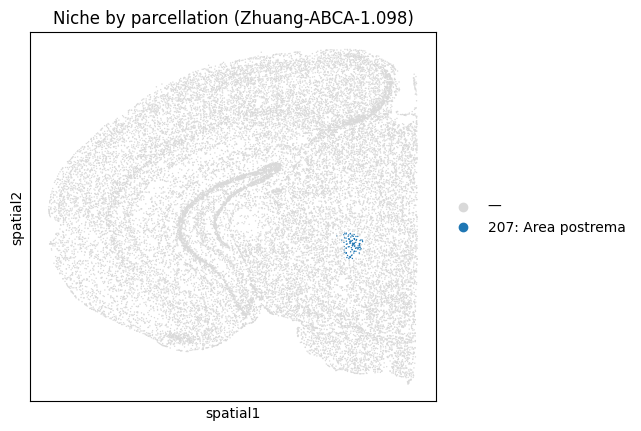

In [5]:
# step 2: construct niche to query;

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='267504471830606554974249492302877563377', sample_id=query_niche_sample_id, \
    k=8, cell_limit=100, parcellation_index=target_parcellation)
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.30
INFO:sr

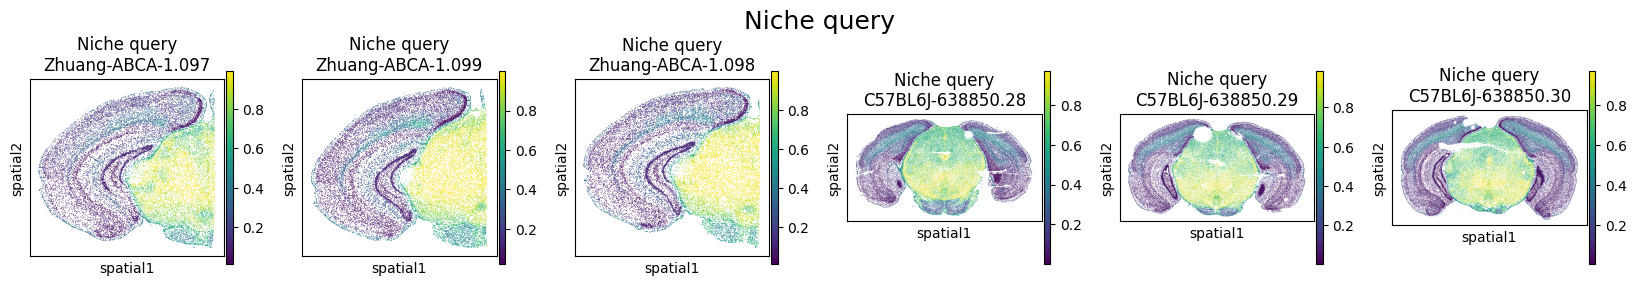

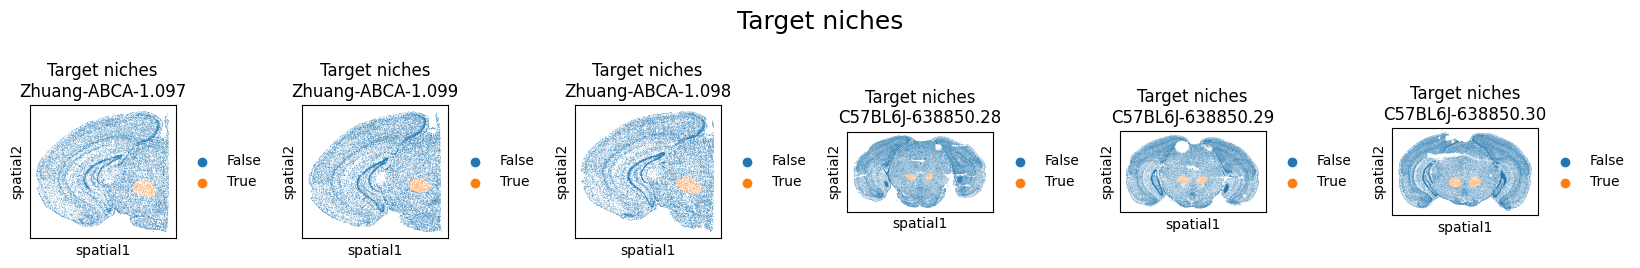

In [6]:
# step 3: run niche query on given samples
import matplotlib.pyplot as plt
import scanpy as sc

niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.niche_query_visualization(query_samples, show_target_niches=True)

In [7]:
# step 4: classification report
niche_query.niche_query_quantitive_metrics(search_samples=query_samples, \
    result_txt_path='notebook/ccf/data/benchmark_samples/20260414_235933/quantitive_metrics/quest.txt')

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.30
INFO:sr

[{'sample_id': 'Zhuang-ABCA-1.097',
  'auprc': 0.5219132598801675,
  'pcc': 0.22456510894738774,
  'avg_ncjs': 0.8704278059480072,
  'avg_bio': 0.24158830283764102,
  'avg_batch': nan},
 {'sample_id': 'Zhuang-ABCA-1.099',
  'auprc': 0.21826659982054614,
  'pcc': 0.20097897621169458,
  'avg_ncjs': 0.8803844991153121,
  'avg_bio': 0.25842729229593137,
  'avg_batch': nan},
 {'sample_id': 'Zhuang-ABCA-1.098',
  'auprc': 0.47544311381403404,
  'pcc': 0.23069821659415268,
  'avg_ncjs': 0.8709185003387094,
  'avg_bio': 0.2394661958113898,
  'avg_batch': nan},
 {'sample_id': 'C57BL6J-638850.28',
  'auprc': 0.052199713448893875,
  'pcc': 0.13628290327020093,
  'avg_ncjs': 0.896629468996962,
  'avg_bio': 0.21710751376306006,
  'avg_batch': nan},
 {'sample_id': 'C57BL6J-638850.29',
  'auprc': 0.10338850235720003,
  'pcc': 0.1921372154235078,
  'avg_ncjs': 0.8934978152546476,
  'avg_bio': 0.2388002326685934,
  'avg_batch': nan},
 {'sample_id': 'C57BL6J-638850.30',
  'auprc': 0.4481754402333902,
  

## Gene Expressions

In [2]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery

# step 1: create db
zhuang_abca_1_folder = 'notebook/ccf/data/zhuang-abca-1/'
zhuang_abca_2_folder = 'notebook/ccf/data/zhuang-abca-2/'
zhuang_abca_3_folder = 'notebook/ccf/data/zhuang-abca-3/'
zeng_mwb_folder = 'notebook/ccf/data/zeng-mwb/'
sample_data_folder = 'notebook/ccf/data/benchmark_samples/20260414_235933'

# target_sample_ids = [
#     'Zhuang-ABCA-1.098', 'Zhuang-ABCA-1.099', 'Zhuang-ABCA-1.097', #'Zhuang-ABCA-1.096',
#     #'Zhuang-ABCA-2.046', 'Zhuang-ABCA-2.047', 'Zhuang-ABCA-2.048', #'Zhuang-ABCA-2.050',
#     #'Zhuang-ABCA-3.001', 'Zhuang-ABCA-3.002', 'Zhuang-ABCA-3.004', #'Zhuang-ABCA-3.005',
#     'C57BL6J-638850.28', 'C57BL6J-638850.29', 'C57BL6J-638850.30', #'C57BL6J-638850.31'
# ]
target_sample_ids = [
    'Zhuang-ABCA-1.098'
]

db = Database(target_sample_ids)

db.construct(
    adata_path=[
        sample_data_folder + '/' + sample_id + '.h5ad'
        for sample_id in target_sample_ids
    ],
    cell_metadata_path=[
        zhuang_abca_1_folder + 'cell_metadata.csv',
        zhuang_abca_2_folder + 'cell_metadata.csv',
        zhuang_abca_3_folder + 'cell_metadata.csv',
        zeng_mwb_folder + 'cell_metadata.csv',
    ],
    ccf_coordinates_path=[
        zhuang_abca_1_folder + 'ccf_coordinates.csv',
        zhuang_abca_2_folder + 'ccf_coordinates.csv',
        zhuang_abca_3_folder + 'ccf_coordinates.csv',
        zeng_mwb_folder + 'ccf_coordinates.csv',
    ],
    feature_name='gene_expression',
    parcellation_path='notebook/ccf/data/parcellation/structure.json'
)


/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Loading CCF coordinates...
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:361: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunksize=_METADATA_CSV_CHUNKSIZE):
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:361: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunk

In [ ]:
# (optional) export sample slices
# db.export_sample_adata('notebook/ccf/data/benchmark_samples')

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.098 slice.
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.098')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:257: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'sample_id' as categorical


Niche cells by parcellation (n_total=100):
  parcellation_index=207  parcellation_name='Area postrema'  n_cells=26
  parcellation_index=303  parcellation_name='Basolateral amygdalar nucleus, anterior part'  n_cells=74


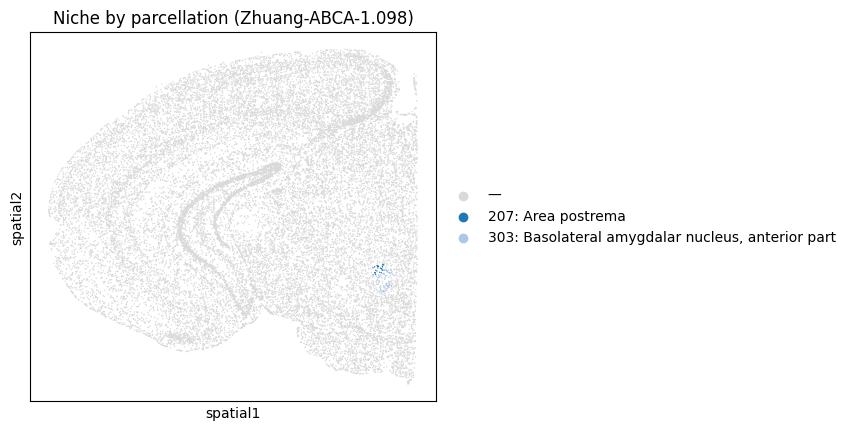

In [4]:
# step 2: construct niche to query;
query_niche_sample_id = 'Zhuang-ABCA-1.098'

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='135815520852954369042806337923633344942', sample_id=query_niche_sample_id, \
    k=8, cell_limit=100, parcellation_index=[207,303])
niche_to_query.visualize(db)

In [ ]:
# step 3: compute ground truth

import matplotlib.pyplot as plt
import scanpy as sc

niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.compute_rm_ideal_score(query_niche_cells=niche_to_query.cells, samples=query_samples)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.30
INFO:sr

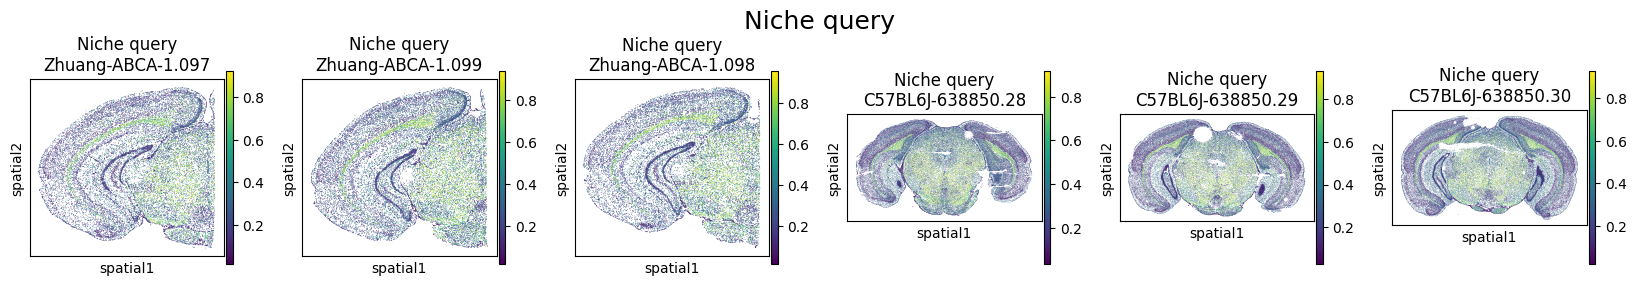

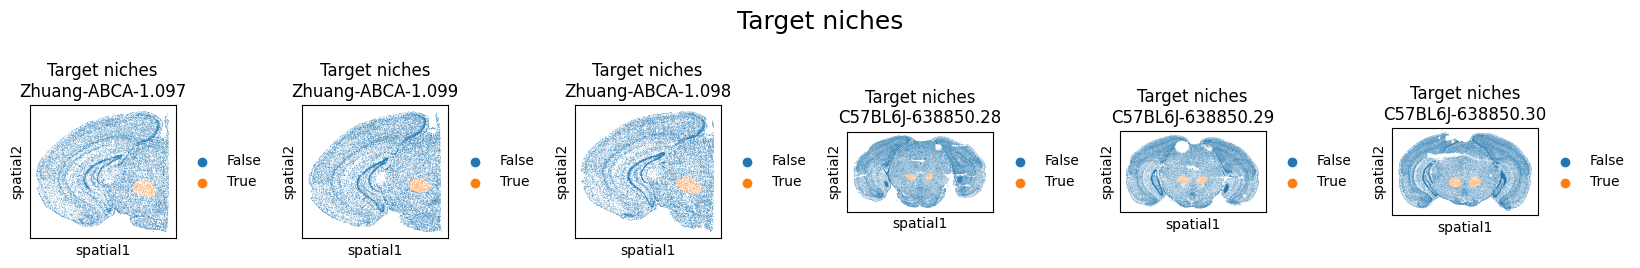

In [ ]:
# step 4: run niche query on given samples

niche_query.niche_query_visualization(query_samples, show_target_niches=True)

In [6]:
# step 4: classification report
niche_query.niche_query_quantitive_metrics(search_samples=query_samples, \
    result_txt_path='notebook/ccf/data/benchmark_samples/20260414_235933/quantitive_metrics/raw_gene_expression.txt')

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.30
INFO:sr

[{'sample_id': 'Zhuang-ABCA-1.097',
  'auprc': 0.07774216440120958,
  'pcc': 0.16704711524640573,
  'avg_ncjs': 0.4763526123208065,
  'avg_bio': 0.011710566924743296,
  'avg_batch': nan},
 {'sample_id': 'Zhuang-ABCA-1.099',
  'auprc': 0.05055891562320611,
  'pcc': 0.12326610709492332,
  'avg_ncjs': 0.4694843765740744,
  'avg_bio': 0.017886340093281328,
  'avg_batch': nan},
 {'sample_id': 'Zhuang-ABCA-1.098',
  'auprc': 0.08614021790616587,
  'pcc': 0.16775279369949192,
  'avg_ncjs': 0.46589839606415323,
  'avg_bio': 0.012803134859591206,
  'avg_batch': nan},
 {'sample_id': 'C57BL6J-638850.28',
  'auprc': 0.0314869854647359,
  'pcc': 0.09267512502479992,
  'avg_ncjs': 0.5467500531140473,
  'avg_bio': 0.04195348515579302,
  'avg_batch': nan},
 {'sample_id': 'C57BL6J-638850.29',
  'auprc': 0.06145235542297741,
  'pcc': 0.13502907221157037,
  'avg_ncjs': 0.5411206684546427,
  'avg_bio': 0.0450217019746593,
  'avg_batch': nan},
 {'sample_id': 'C57BL6J-638850.30',
  'auprc': 0.09237118337516